<a href="https://colab.research.google.com/github/rafi1624/Machine-Learning_18_Rafi-Abyantara/blob/main/JS05/JS%2005-Tugas%20Lab%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv.

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [9]:
# 1. Memuat Dataset
df = pd.read_csv("voice.csv")

In [10]:
# 2. Preprocessing Data
X = df.drop('label', axis=1)
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# 3. Pembagian Data (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [12]:
# 4. Membuat dan Melatih Model kNN
knn_model = KNeighborsClassifier(n_neighbors=4)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4)

In [13]:
# 5. Evaluasi Model
y_pred = knn_model.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model kNN: {akurasi * 100:.2f}%")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=['Female (0)', 'Male (1)']))

Akurasi Model kNN: 97.79%

Laporan Klasifikasi:
              precision    recall  f1-score   support

  Female (0)       0.96      0.99      0.98       297
    Male (1)       0.99      0.97      0.98       337

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?

In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif

In [15]:
# 1. Memuat Dataset
df = pd.read_csv("voice.csv")

In [16]:

# 2. Preprocessing Data
X = df.drop('label', axis=1)
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [17]:
# 3. Percobaan Seleksi Fitur (Feature Selection)
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled_df, y_encoded)


feature_scores = pd.DataFrame({
    'Fitur': X.columns,
    'Skor F-Value': selector.scores_
})
feature_scores = feature_scores.sort_values(by='Skor F-Value', ascending=False)
feature_scores.reset_index(drop=True, inplace=True)

print("Peringkat Kepentingan Fitur (dari yang paling optimal):")
print(feature_scores)

Peringkat Kepentingan Fitur (dari yang paling optimal):
       Fitur  Skor F-Value
0    meanfun   7228.790362
1        IQR   1965.750000
2        Q25   1121.569224
3     sp.ent   1003.308717
4         sd    945.461376
5        sfm    463.923194
6   centroid    406.752820
7   meanfreq    406.752820
8     median    277.588158
9     maxdom    126.024161
10    mindom    125.110999
11   dfrange    121.457858
12   meandom    119.959108
13      mode     96.257909
14    maxfun     90.228036
15    minfun     60.282137
16      kurt     24.255365
17       Q75     14.236082
18      skew      4.252980
19   modindx      3.006445


In [21]:
# 4. Memilih Fitur Terbaik
fitur_terbaik = feature_scores['Fitur'].head(5).tolist()

print(f"Fitur yang digunakan untuk hasil terbaik: {fitur_terbaik}")

Fitur yang digunakan untuk hasil terbaik: ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd']



3. Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai
k
k yang terbaik? Lampirkan grafika analisis dan alasan Anda.

Berdasarkan 5 fitur terbaik, K terbaik adalah 4 atau 6, karena keduanya memiliki akurasi validasi silang tertinggi, sekitar 97,87%. Untuk kNN biner, K ganjil juga dapat dipilih untuk menghindari tie, misalnya K=5 dengan akurasi yang hampir sama.Berikut grafiknya

Nilai K terbaik adalah: 4 dengan rata-rata akurasi CV sebesar 0.9787


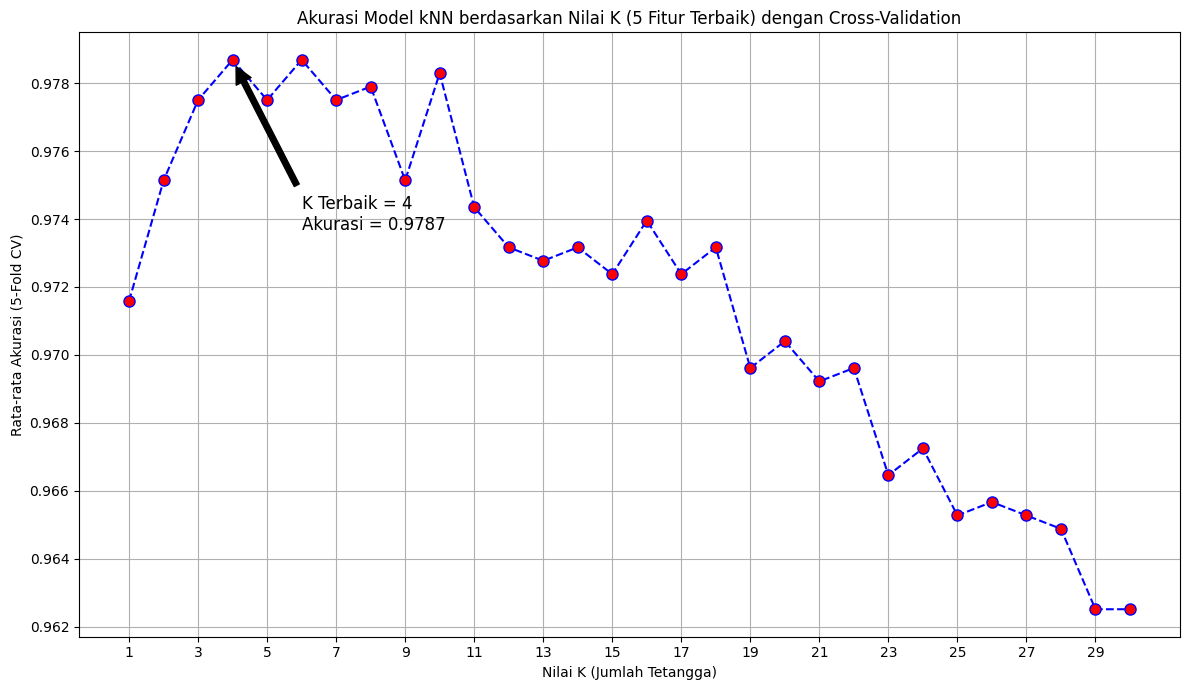

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

X_best_features = X_scaled_df[fitur_terbaik]
X_train_bf, X_test_bf, y_train_bf, y_test_bf = train_test_split(X_best_features, y_encoded, test_size=0.2, random_state=42)
k_values = list(range(1, 31))
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_bf, y_train_bf, cv=5)
    accuracies.append(scores.mean())


best_k_index = np.argmax(accuracies)
best_k = k_values[best_k_index]
best_accuracy = accuracies[best_k_index]

print(f"Nilai K terbaik adalah: {best_k} dengan rata-rata akurasi CV sebesar {best_accuracy:.4f}")


plt.figure(figsize=(12, 7))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='blue', markerfacecolor='red', markersize=8)
plt.title('Akurasi Model kNN berdasarkan Nilai K (5 Fitur Terbaik) dengan Cross-Validation')
plt.xlabel('Nilai K (Jumlah Tetangga)')
plt.ylabel('Rata-rata Akurasi (5-Fold CV)')


plt.annotate(f'K Terbaik = {best_k}\nAkurasi = {best_accuracy:.4f}',
             xy=(best_k, best_accuracy),
             xytext=(best_k + 2, best_accuracy - 0.005),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12)


plt.xticks(np.arange(1, 31, step=2))
plt.grid(True)
plt.tight_layout()
plt.show()
